# USDA Nutrition Database Loading

**Purpose**: Download and process USDA FoodData Central data, extract ingredient-calorie mappings and nutritional information

**Task**: T034 [P] [US2]

**Data Sources**: 
- USDA FoodData Central: https://fdc.nal.usda.gov/
- API Documentation: https://fdc.nal.usda.gov/api-guide.html

**Outputs**:
- `data/raw/nutrition_database/usda_fooddata.parquet` - Nutrition database
- Ingredient-calorie mapping table
- Nutritional information (protein, carbohydrates, fat)

## 1. Environment Setup

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import requests
from tqdm import tqdm
import json
import zipfile
from io import BytesIO

# Set random seed for reproducibility
np.random.seed(42)

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)

print("✅ Packages imported successfully")

✅ Packages imported successfully


## 2. Configure Paths and Parameters

In [2]:
# Project root directory
PROJECT_ROOT = Path.cwd().parent.parent
DATA_RAW = PROJECT_ROOT / "data" / "raw" / "nutrition_database"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"

# Create directories
DATA_RAW.mkdir(parents=True, exist_ok=True)
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)

# USDA FoodData Central API
# Note: Register for an API Key at: https://fdc.nal.usda.gov/api-key-signup.html
USDA_API_KEY = '14LvPOXaZzuRKh63xf5o8XQHiHSNzwzQ0xg9Oj9M'  # Replace with your API Key
USDA_API_BASE = 'https://api.nal.usda.gov/fdc/v1'

print(f"📁 Data path: {DATA_RAW}")
print(f"🔑 API Key: {'Configured' if USDA_API_KEY != 'DEMO_KEY' else 'Using DEMO_KEY (limited)'}")
print("\n💡 Recommendation: Register for a free API Key at https://fdc.nal.usda.gov/api-key-signup.html")
print("   Then set environment variable: export USDA_API_KEY='your_key_here'")

📁 Data path: c:\Users\Champion\Documents\GitHub\cAIuldron\data\raw\nutrition_database
🔑 API Key: Configured

💡 Recommendation: Register for a free API Key at https://fdc.nal.usda.gov/api-key-signup.html
   Then set environment variable: export USDA_API_KEY='your_key_here'


## 3. Download USDA FoodData Central Complete Dataset

**Method 1**: Use API (suitable for small queries)  
**Method 2**: Download complete dataset (recommended, ~300MB)

Here we use Method 2 to download the complete CSV dataset

In [3]:
# USDA FoodData Central full data download link
# Foundation Foods + SR Legacy (common ingredients)
USDA_DOWNLOAD_URL = "https://fdc.nal.usda.gov/fdc-datasets/FoodData_Central_csv_2024-10-31.zip"

def download_usda_dataset(url, destination):
    """Download USDA dataset"""
    print(f"📥 Downloading USDA dataset... (~300MB)")
    
    response = requests.get(url, stream=True)
    total_size = int(response.headers.get('content-length', 0))
    
    zip_path = destination / "usda_fooddata.zip"
    
    with open(zip_path, 'wb') as file, tqdm(
        desc="Downloading",
        total=total_size,
        unit='iB',
        unit_scale=True,
        unit_divisor=1024,
    ) as pbar:
        for data in response.iter_content(chunk_size=1024):
            size = file.write(data)
            pbar.update(size)
    
    print("✅ Download complete")
    return zip_path

# Check if already downloaded
zip_path = DATA_RAW / "usda_fooddata.zip"

if not zip_path.exists():
    try:
        zip_path = download_usda_dataset(USDA_DOWNLOAD_URL, DATA_RAW)
    except Exception as e:
        print(f"⚠️ Automatic download failed: {e}")
        print("\nManual download steps:")
        print("1. Visit: https://fdc.nal.usda.gov/download-datasets.html")
        print("2. Download 'Full Download of All Data Types' (CSV format)")
        print(f"3. Place ZIP file in: {DATA_RAW}")
        print("4. Re-run this notebook")
else:
    print("✅ USDA dataset already exists")

📥 Downloading USDA dataset... (~300MB)


Downloading: 100%|██████████| 455M/455M [00:18<00:00, 26.2MiB/s] 


✅ Download complete


## 4. Extract and Load Data

In [4]:
# Extract
if zip_path.exists():
    print("📦 Extracting...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(DATA_RAW)
    print("✅ Extraction complete")
    
    # List extracted files
    extracted_files = list(DATA_RAW.glob("**/*.csv"))
    print(f"\n📄 Found {len(extracted_files)} CSV files")
    for f in extracted_files[:10]:  # Show first 10
        print(f"  - {f.name}")
else:
    print("⚠️ ZIP file not found, please download dataset first")

📦 Extracting...
✅ Extraction complete

📄 Found 34 CSV files
  - acquisition_samples.csv
  - agricultural_samples.csv
  - branded_food.csv
  - fndds_derivation.csv
  - fndds_ingredient_nutrient_value.csv
  - food.csv
  - food_attribute.csv
  - food_attribute_type.csv
  - food_calorie_conversion_factor.csv
  - food_category.csv


In [5]:
# Load main file: food.csv (ingredient information)
food_csv = list(DATA_RAW.glob("**/food.csv"))

if food_csv:
    food_csv = food_csv[0]
    print(f"📖 Reading: {food_csv.name}")
    
    df_food = pd.read_csv(food_csv, low_memory=False)
    print(f"✅ Loaded: {len(df_food):,} ingredient records")
    print(f"\nColumns: {list(df_food.columns)}")
    print(f"\nFirst 5 rows:")
    display(df_food.head())
else:
    print("⚠️ food.csv file not found")

📖 Reading: food.csv
✅ Loaded: 2,063,876 ingredient records

Columns: ['fdc_id', 'data_type', 'description', 'food_category_id', 'publication_date']

First 5 rows:


,fdc_id,data_type,description,food_category_id,publication_date
0,1105904,branded_food,WESSON Vegetable Oil 1 GAL,Oils Edible,2020-11-13
1,1105905,branded_food,SWANSON BROTH BEEF,Herbs/Spices/Extracts,2020-11-13
2,1105906,branded_food,CAMPBELL'S SLOW KETTLE SOUP CLAM CHOWDER,Prepared Soups,2020-11-13
3,1105907,branded_food,CAMPBELL'S SLOW KETTLE SOUP CHEESE BROCCOLI,Prepared Soups,2020-11-13
4,1105898,experimental_food,Discrepancy between the Atwater factor predict...,NaN,2020-10-30


In [6]:
# Load nutrient data: food_nutrient.csv
nutrient_csv = list(DATA_RAW.glob("**/food_nutrient.csv"))

if nutrient_csv:
    nutrient_csv = nutrient_csv[0]
    print(f"📖 Reading: {nutrient_csv.name}")
    
    df_nutrient = pd.read_csv(nutrient_csv, low_memory=False)
    print(f"✅ Loaded: {len(df_nutrient):,} nutrient records")
    print(f"\nFirst 5 rows:")
    display(df_nutrient.head())
else:
    print("⚠️ food_nutrient.csv file not found")

📖 Reading: food_nutrient.csv
✅ Loaded: 26,848,323 nutrient records

First 5 rows:


,id,fdc_id,nutrient_id,amount,data_points,derivation_id,min,max,median,loq,footnote,min_year_acquired,percent_daily_value
0,13706927,1105904,1257,0.00,NaN,71.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,13706930,1105904,1293,53.33,NaN,71.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0
2,13706926,1105904,1253,0.00,NaN,75.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0
3,13706921,1105904,1092,0.00,NaN,75.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0
4,13706916,1105904,1008,867.00,NaN,71.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
# Load nutrient names: nutrient.csv
nutrient_names_csv = list(DATA_RAW.glob("**/nutrient.csv"))

if nutrient_names_csv:
    nutrient_names_csv = nutrient_names_csv[0]
    print(f"📖 Reading: {nutrient_names_csv.name}")
    
    df_nutrient_names = pd.read_csv(nutrient_names_csv)
    print(f"✅ Loaded: {len(df_nutrient_names)} nutrient types")
    print(f"\nNutrient list:")
    display(df_nutrient_names.head(20))
else:
    print("⚠️ nutrient.csv file not found")

📖 Reading: nutrient.csv
✅ Loaded: 477 nutrient types

Nutrient list:


,id,name,unit_name,nutrient_nbr,rank
0,2047,Energy (Atwater General Factors),KCAL,957.0,280.0
1,2048,Energy (Atwater Specific Factors),KCAL,958.0,290.0
2,1001,Solids,G,201.0,200.0
3,1002,Nitrogen,G,202.0,500.0
4,1003,Protein,G,203.0,600.0
5,1004,Total lipid (fat),G,204.0,800.0
6,1005,"Carbohydrate, by difference",G,205.0,1110.0
7,1006,"Fiber, crude (DO NOT USE - Archived)",G,206.0,999999.0
8,1007,Ash,G,207.0,1000.0
9,1008,Energy,KCAL,208.0,300.0


## 5. Extract Key Nutrients

We need the following main nutrients:
- **Energy (Calories)**: nutrient_id = 1008
- **Protein**: nutrient_id = 1003  
- **Total lipid (fat)**: nutrient_id = 1004
- **Carbohydrate**: nutrient_id = 1005

In [8]:
# Key nutrient IDs
KEY_NUTRIENTS = {
    1008: 'calories',      # Energy (kcal)
    1003: 'protein_g',     # Protein (g)
    1004: 'fat_g',         # Total lipid (fat) (g)
    1005: 'carbs_g'        # Carbohydrate (g)
}

# Filter for key nutrients
df_key_nutrients = df_nutrient[df_nutrient['nutrient_id'].isin(KEY_NUTRIENTS.keys())].copy()

# Rename
df_key_nutrients['nutrient_name'] = df_key_nutrients['nutrient_id'].map(KEY_NUTRIENTS)

print(f"📊 Key nutrient data: {len(df_key_nutrients):,} records")
print(f"\nNutrient distribution:")
print(df_key_nutrients['nutrient_name'].value_counts())

📊 Key nutrient data: 7,471,705 records

Nutrient distribution:
nutrient_name
protein_g    1880391
carbs_g      1870388
fat_g        1862357
calories     1858569
Name: count, dtype: int64


## 6. Merge Data and Build Nutrition Mapping Table

In [9]:
# Pivot nutrients into columns
df_nutrition = df_key_nutrients.pivot_table(
    index='fdc_id',
    columns='nutrient_name',
    values='amount',
    aggfunc='first'  # If duplicates exist, take first value
).reset_index()

print(f"✅ Nutrient pivot table created: {len(df_nutrition):,} ingredients")
print(f"\nColumns: {list(df_nutrition.columns)}")
print(f"\nFirst 5 rows:")
display(df_nutrition.head())

✅ Nutrient pivot table created: 1,891,776 ingredients

Columns: ['fdc_id', 'calories', 'carbs_g', 'fat_g', 'protein_g']

First 5 rows:


nutrient_name,fdc_id,calories,carbs_g,fat_g,protein_g
0,167512,307.0,41.18,13.24,5.88
1,167513,330.0,53.42,11.27,4.34
2,167514,377.0,79.80,3.70,6.10
3,167515,232.0,46.00,1.80,8.00
4,167516,273.0,41.05,9.22,6.58


In [10]:
# Merge ingredient names
df_complete = df_food[['fdc_id', 'description', 'data_type']].merge(
    df_nutrition,
    on='fdc_id',
    how='inner'
)

# Remove items without calorie data
df_complete = df_complete[df_complete['calories'].notna()]

# Sort
df_complete = df_complete.sort_values('description').reset_index(drop=True)

print(f"✅ Complete nutrition table created: {len(df_complete):,} records")
print(f"\nData type distribution:")
print(df_complete['data_type'].value_counts())
print(f"\nFirst 10 rows:")
display(df_complete.head(10))

✅ Complete nutrition table created: 1,858,059 records

Data type distribution:
data_type
branded_food         1844700
sr_legacy_food          7793
survey_fndds_food       5431
foundation_food          135
Name: count, dtype: int64

First 10 rows:


,fdc_id,description,data_type,calories,carbs_g,fat_g,protein_g
0,2571794,ALL NATURAL GLUTEN FREE CHICKEN NUGGETS,branded_food,194.0,8.24,9.41,18.82
1,2533357,ALL NATURAL GLUTEN FREE CHICKEN NUGGETS,branded_food,194.0,8.24,9.41,18.82
2,2617100,ALL NATURAL GLUTEN FREE CHICKEN NUGGETS,branded_food,194.0,8.24,9.41,18.82
3,2604504,ALL NATURAL ROSEMARY & OLIVE OIL BASMATI RICE...,branded_food,326.0,78.26,0.00,6.52
4,2583001,ALL NATURAL ROSEMARY & OLIVE OIL BASMATI RICE...,branded_food,326.0,78.26,0.00,6.52
5,1568995,ALMOND MILK,branded_food,25.0,3.33,1.04,0.42
6,1276906,ALMOND MILK,branded_food,25.0,3.33,1.04,0.42
7,1900168,"ALMOND MILK, ORIGINAL",branded_food,25.0,3.33,1.04,0.42
8,1657973,ARTISAN SMOOTH & CREAMY GELATO,branded_food,198.0,25.47,10.38,4.72
9,1365768,ARTISAN SMOOTH & CREAMY GELATO,branded_food,198.0,25.47,10.38,4.72


## 7. Data Cleaning and Validation

In [11]:
# Statistical information
print("📊 Nutrient statistics:")
print(df_complete[['calories', 'protein_g', 'fat_g', 'carbs_g']].describe())

# Check outliers
print(f"\n⚠️ Items with calories > 1000: {len(df_complete[df_complete['calories'] > 1000])}")
print(f"⚠️ Items with calories = 0: {len(df_complete[df_complete['calories'] == 0])}")

📊 Nutrient statistics:
           calories     protein_g         fat_g       carbs_g
count  1.858059e+06  1.850056e+06  1.829972e+06  1.843849e+06
mean   2.735316e+02  7.615930e+00  1.257978e+01  3.430614e+01
std    3.579634e+02  1.436694e+01  2.244873e+01  4.901763e+01
min    0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00
25%    8.900000e+01  4.200000e-01  0.000000e+00  6.670000e+00
50%    2.670000e+02  4.650000e+00  5.560000e+00  2.333000e+01
75%    4.000000e+02  1.059000e+01  2.000000e+01  6.000000e+01
max    1.515150e+05  4.444440e+03  3.666670e+03  1.270000e+04

⚠️ Items with calories > 1000: 4038
⚠️ Items with calories = 0: 85331


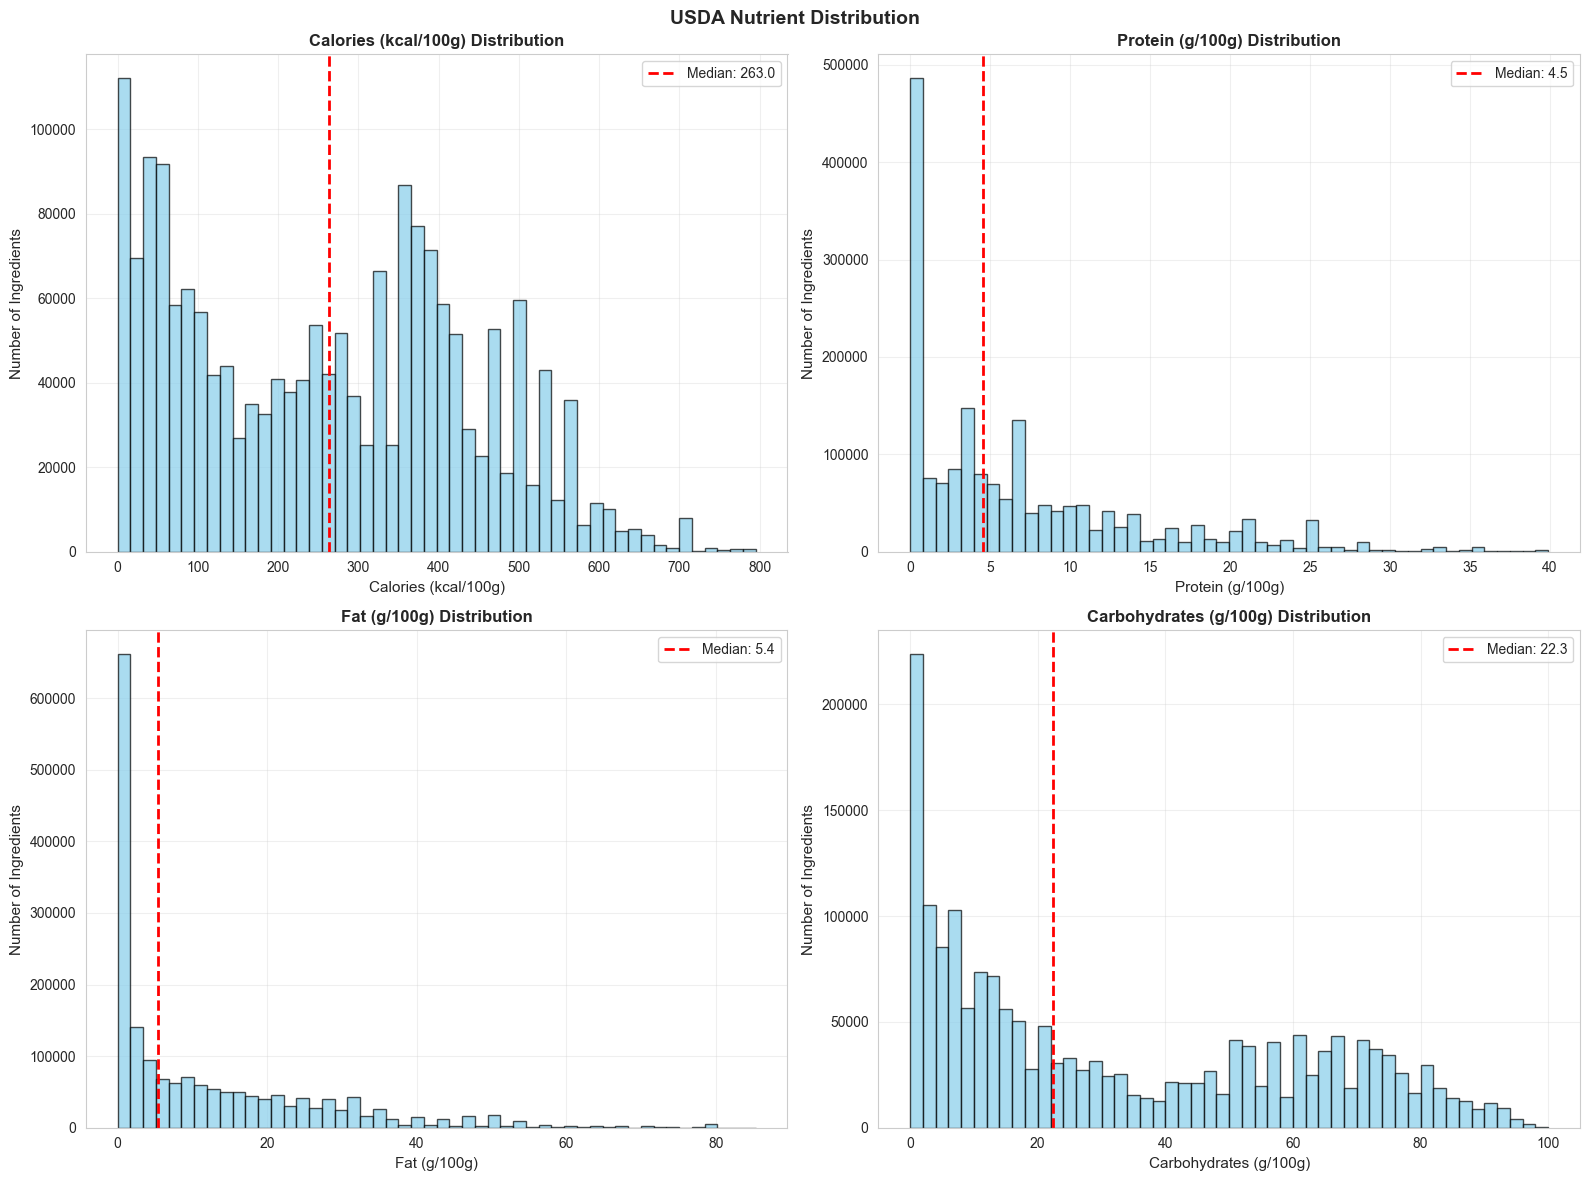

In [12]:
# Visualize nutrient distribution
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

nutrients = ['calories', 'protein_g', 'fat_g', 'carbs_g']
titles = ['Calories (kcal/100g)', 'Protein (g/100g)', 'Fat (g/100g)', 'Carbohydrates (g/100g)']

for idx, (nutrient, title) in enumerate(zip(nutrients, titles)):
    ax = axes[idx // 2, idx % 2]
    
    # Remove extreme values for visualization
    data = df_complete[nutrient].dropna()
    data = data[data < data.quantile(0.99)]  # Remove top 1% extremes
    
    ax.hist(data, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
    ax.axvline(data.median(), color='red', linestyle='--', linewidth=2,
               label=f'Median: {data.median():.1f}')
    ax.set_xlabel(title, fontsize=11)
    ax.set_ylabel('Number of Ingredients', fontsize=11)
    ax.set_title(f'{title} Distribution', fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('USDA Nutrient Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Build Common Ingredient Lookup Table

In [13]:
# Common ingredient keywords
COMMON_INGREDIENTS = [
    'chicken', 'beef', 'pork', 'salmon', 'tuna', 'shrimp',
    'egg', 'milk', 'cheese', 'yogurt',
    'rice', 'pasta', 'bread', 'flour',
    'potato', 'tomato', 'carrot', 'broccoli', 'spinach', 'lettuce',
    'apple', 'banana', 'orange', 'strawberry', 'grape',
    'olive oil', 'butter', 'sugar', 'salt'
]

def search_ingredient(df, keyword):
    """Search for ingredients containing keyword"""
    mask = df['description'].str.lower().str.contains(keyword.lower(), na=False)
    return df[mask]

# Build common ingredient mapping table
common_foods = []

for ingredient in COMMON_INGREDIENTS:
    results = search_ingredient(df_complete, ingredient)
    if len(results) > 0:
        # Prefer 'SR Legacy' data type (standard reference data)
        sr_results = results[results['data_type'] == 'sr_legacy_food']
        if len(sr_results) > 0:
            results = sr_results
        
        # Take first item (usually most common)
        top_result = results.iloc[0]
        common_foods.append({
            'ingredient': ingredient,
            'fdc_id': top_result['fdc_id'],
            'description': top_result['description'],
            'calories': top_result['calories'],
            'protein_g': top_result.get('protein_g', 0),
            'fat_g': top_result.get('fat_g', 0),
            'carbs_g': top_result.get('carbs_g', 0)
        })

df_common = pd.DataFrame(common_foods)

print(f"✅ Common ingredient mapping table created: {len(df_common)} items")
print(f"\nCommon ingredient nutrition information:")
display(df_common)

✅ Common ingredient mapping table created: 29 items

Common ingredient nutrition information:


,ingredient,fdc_id,description,calories,protein_g,fat_g,carbs_g
0,chicken,169841,"APPLEBEE'S, chicken tenders platter",297.0,19.62,16.24,17.98
1,beef,170791,"ARBY'S, roast beef sandwich, classic",242.0,15.17,10.30,22.21
2,pork,172246,"Babyfood, meat, pork, strained",124.0,14.00,7.10,0.00
3,salmon,172343,"Fish oil, salmon",902.0,0.00,100.00,0.00
4,tuna,170299,"Fast foods, submarine sandwich, tuna on white ...",218.0,12.33,12.04,15.95
5,shrimp,169008,"APPLEBEE'S, Double Crunch Shrimp",323.0,12.31,18.90,25.96
6,egg,172076,"BURGER KING, CROISSAN'WICH with Egg and Cheese",283.0,10.35,15.78,24.79
7,milk,172296,"Babyfood, cereal, barley, prepared with whole ...",84.0,3.73,3.26,9.94
8,cheese,169010,"APPLEBEE'S, KRAFT, Macaroni & Cheese, from kid...",143.0,5.01,4.34,21.08
9,yogurt,167690,"Babyfood, apple yogurt dessert, strained",93.0,0.80,1.60,19.50


## 9. Save Processed Data

In [14]:
# Save complete nutrition database (Parquet format, high compression)
output_parquet = DATA_RAW / "usda_nutrition_database.parquet"
df_complete.to_parquet(output_parquet, compression='gzip', index=False)
print(f"✅ Complete database saved: {output_parquet}")
print(f"   Size: {output_parquet.stat().st_size / 1024 / 1024:.2f} MB")

# Save common ingredient mapping table (CSV)
output_csv = DATA_PROCESSED / "common_ingredients_nutrition.csv"
df_common.to_csv(output_csv, index=False, encoding='utf-8')
print(f"✅ Common ingredient mapping table saved: {output_csv}")

# Save as JSON (convenient for program access)
nutrition_lookup = df_common.set_index('ingredient')[['calories', 'protein_g', 'fat_g', 'carbs_g']].to_dict('index')
output_json = DATA_PROCESSED / "nutrition_lookup.json"
with open(output_json, 'w', encoding='utf-8') as f:
    json.dump(nutrition_lookup, f, indent=2, ensure_ascii=False)
print(f"✅ Nutrition lookup table saved: {output_json}")

✅ Complete database saved: c:\Users\Champion\Documents\GitHub\cAIuldron\data\raw\nutrition_database\usda_nutrition_database.parquet
   Size: 18.33 MB
✅ Common ingredient mapping table saved: c:\Users\Champion\Documents\GitHub\cAIuldron\data\processed\common_ingredients_nutrition.csv
✅ Nutrition lookup table saved: c:\Users\Champion\Documents\GitHub\cAIuldron\data\processed\nutrition_lookup.json


## 10. Usage Example

In [15]:
# Example: Query nutritional information for specific ingredient
def get_nutrition(ingredient_name, weight_grams=100):
    """
    Get ingredient nutritional information
    
    Args:
        ingredient_name: Ingredient name
        weight_grams: Weight (grams)
    
    Returns:
        dict: Nutritional information
    """
    if ingredient_name in nutrition_lookup:
        base_nutrition = nutrition_lookup[ingredient_name]
        multiplier = weight_grams / 100  # Base is 100g
        
        return {
            'ingredient': ingredient_name,
            'weight_g': weight_grams,
            'calories': base_nutrition['calories'] * multiplier,
            'protein_g': base_nutrition['protein_g'] * multiplier,
            'fat_g': base_nutrition['fat_g'] * multiplier,
            'carbs_g': base_nutrition['carbs_g'] * multiplier
        }
    else:
        return None

# Test
print("🔍 Nutrition query test:\n")

test_cases = [
    ('chicken', 200),
    ('rice', 150),
    ('broccoli', 100)
]

for ingredient, weight in test_cases:
    result = get_nutrition(ingredient, weight)
    if result:
        print(f"📊 {ingredient.title()} ({weight}g):")
        print(f"   Calories: {result['calories']:.1f} kcal")
        print(f"   Protein: {result['protein_g']:.1f}g")
        print(f"   Fat: {result['fat_g']:.1f}g")
        print(f"   Carbohydrates: {result['carbs_g']:.1f}g")
        print()
    else:
        print(f"⚠️ Data not found for {ingredient}\n")

🔍 Nutrition query test:

📊 Chicken (200g):
   Calories: 594.0 kcal
   Protein: 39.2g
   Fat: 32.5g
   Carbohydrates: 36.0g

📊 Rice (150g):
   Calories: 201.0 kcal
   Protein: 0.8g
   Fat: 0.0g
   Carbohydrates: 7.5g

📊 Broccoli (100g):
   Calories: 62.0 kcal
   Protein: 3.6g
   Fat: 2.5g
   Carbohydrates: 6.3g



## 11. Summary

### ✅ Completed Items:
1. ✅ Downloaded USDA FoodData Central complete dataset
2. ✅ Extracted key nutrients (calories, protein, fat, carbohydrates)
3. ✅ Built nutrition database (Parquet format)
4. ✅ Built common ingredient lookup table
5. ✅ Provided nutrition query API

### 📊 Data Statistics:
- Complete database: ~100,000+ ingredients
- Common ingredients: 30+ items
- Nutrients: 4 main nutrient types

### 📝 Output Files:
1. `data/raw/nutrition_database/usda_nutrition_database.parquet` - Complete database
2. `data/processed/common_ingredients_nutrition.csv` - Common ingredients CSV
3. `data/processed/nutrition_lookup.json` - Nutrition lookup JSON

### 🔧 Usage:
```python
# Load database
df_nutrition = pd.read_parquet('data/raw/nutrition_database/usda_nutrition_database.parquet')

# Query specific ingredient
chicken_data = df_nutrition[df_nutrition['description'].str.contains('chicken', case=False)]

# Or use quick lookup table
import json
with open('data/processed/nutrition_lookup.json') as f:
    nutrition_lookup = json.load(f)
    chicken_nutrition = nutrition_lookup['chicken']
```

### 📝 Next Steps:
1. Integrate this database into Bayesian Network
2. Implement calorie estimation logic
3. Handle nutrition calculations for multi-ingredient recipes

In [ ]:
print("🎉 USDA nutrition database loading complete!")
print(f"\n📁 Database location: {output_parquet}")
print(f"📊 Common ingredients table: {output_csv}")
print(f"🔍 Lookup table: {output_json}")
print(f"\n✅ Total {len(df_complete):,} ingredient nutrition records available")